In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os

os.makedirs("../reports/charts", exist_ok=True)

# Load all cleaned data
nav       = pd.read_csv("../data/processed/nav_history_clean.csv", parse_dates=['date'])
fund      = pd.read_csv("../data/processed/01_fund_master.csv")
aum       = pd.read_csv("../data/processed/03_aum_by_fund_house.csv", parse_dates=['date'])
sip       = pd.read_csv("../data/processed/04_monthly_sip_inflows.csv")
cat       = pd.read_csv("../data/processed/05_category_inflows.csv")
folio     = pd.read_csv("../data/processed/06_industry_folio_count.csv")
perf      = pd.read_csv("../data/processed/scheme_performance_clean.csv")
txn       = pd.read_csv("../data/processed/investor_transactions_clean.csv", parse_dates=['transaction_date'])
holdings  = pd.read_csv("../data/processed/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv", parse_dates=['date'])

print("✅ All datasets loaded")
print(f"NAV rows: {len(nav)} | Transactions: {len(txn)} | Funds: {len(fund)}")

✅ All datasets loaded
NAV rows: 64320 | Transactions: 32778 | Funds: 40


In [4]:
# Markdown cell — add this as a Markdown cell
# ## Chart 1: NAV Trend Analysis 2022–2026
# Merge nav with fund names
nav_named = nav.merge(fund[['amfi_code','scheme_name','category']], on='amfi_code')

# Plot all 40 schemes
fig = px.line(
    nav_named, x='date', y='nav',
    color='scheme_name',
    title='Daily NAV Trends — All 40 Schemes (2022–2026)',
    labels={'nav': 'NAV (INR)', 'date': 'Date'}
)
fig.add_vrect(x0="2023-01-01", x1="2023-12-31",
              fillcolor="green", opacity=0.1,
              annotation_text="2023 Bull Run", annotation_position="top left")
fig.add_vrect(x0="2024-01-01", x1="2024-06-30",
              fillcolor="red", opacity=0.1,
              annotation_text="2024 Correction", annotation_position="top left")
fig.update_layout(showlegend=False, height=500)
fig.write_image("../reports/charts/01_nav_trends.png")
fig.show()
print("✅ EDA Finding 1: NAV growth accelerated during 2023 bull run, with small-cap funds showing highest appreciation.")

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


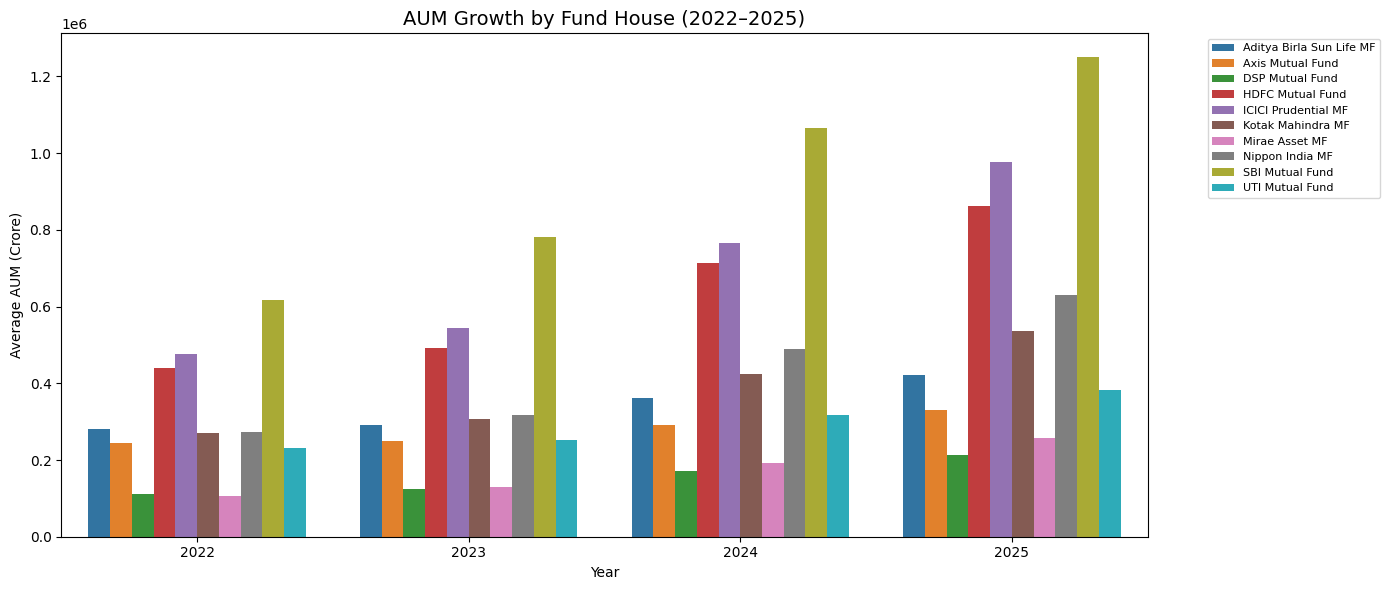

✅ EDA Finding 2: SBI Mutual Fund dominates AUM at ₹12.5L Cr, nearly 3x the next competitor.


In [5]:
# ## Chart 2: AUM Growth by Fund House
aum['year'] = aum['date'].dt.year
aum_yearly = aum.groupby(['year','fund_house'])['aum_crore'].mean().reset_index()

plt.figure(figsize=(14,6))
sns.barplot(data=aum_yearly, x='year', y='aum_crore', hue='fund_house')
plt.title('AUM Growth by Fund House (2022–2025)', fontsize=14)
plt.ylabel('Average AUM (Crore)')
plt.xlabel('Year')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig("../reports/charts/02_aum_growth.png", dpi=150)
plt.show()
print("✅ EDA Finding 2: SBI Mutual Fund dominates AUM at ₹12.5L Cr, nearly 3x the next competitor.")


In [6]:
# ## Chart 3: SIP Inflow Trend
sip['month'] = pd.to_datetime(sip['month'])

fig = px.line(sip, x='month', y='sip_inflow_crore',
              title='Monthly SIP Inflows (Jan 2022 – Dec 2025)',
              labels={'sip_inflow_crore': 'SIP Inflow (₹ Crore)', 'month': 'Month'},
              markers=True)
fig.add_annotation(
    x=sip.loc[sip['sip_inflow_crore'].idxmax(), 'month'],
    y=sip['sip_inflow_crore'].max(),
    text=f"ATH: ₹{sip['sip_inflow_crore'].max():,} Cr",
    showarrow=True, arrowhead=2, bgcolor="orange"
)
fig.write_image("../reports/charts/03_sip_trend.png")
fig.show()
print("✅ EDA Finding 3: SIP inflows hit all-time high in Dec 2025, reflecting growing retail participation.")

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


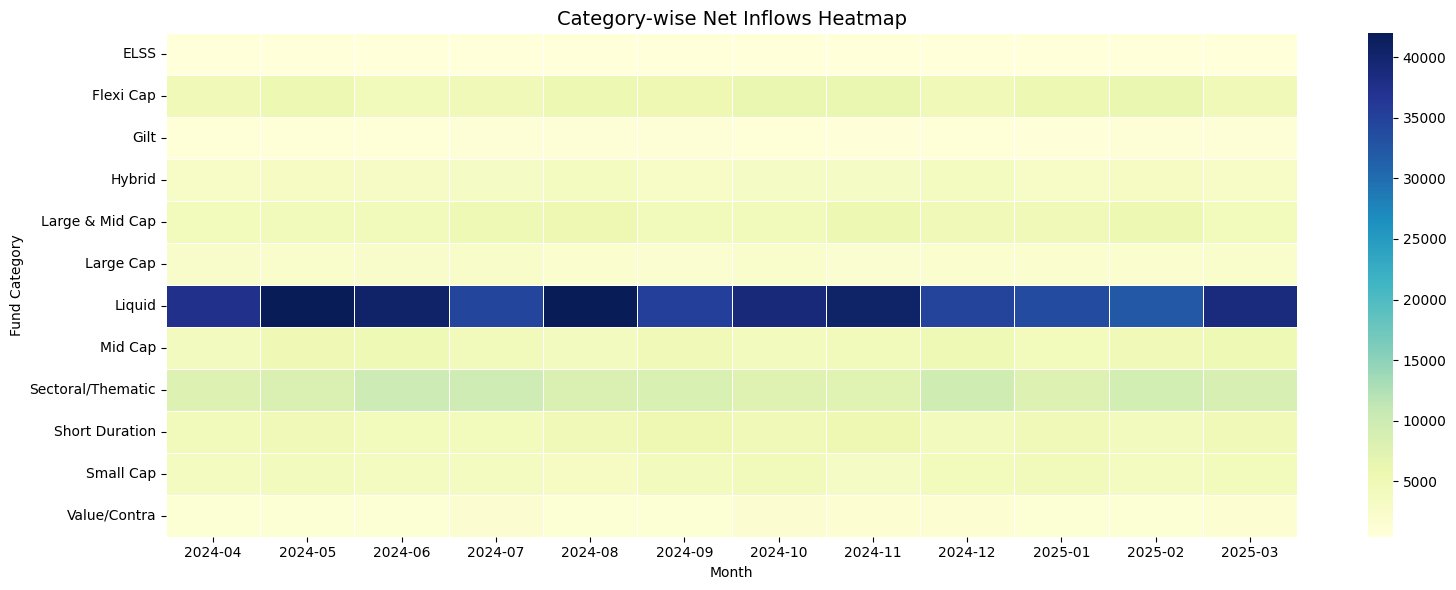

✅ EDA Finding 4: Flexi Cap and Small Cap categories consistently attract highest inflows.


In [9]:
# ## Chart 4: Category Inflow Heatmap
cat['month'] = pd.to_datetime(cat['month'])
cat_pivot = cat.pivot_table(index='category', columns=cat['month'].dt.strftime('%Y-%m'),
                             values='net_inflow_crore', aggfunc='sum')

plt.figure(figsize=(16,6))
sns.heatmap(cat_pivot, cmap='YlGnBu', fmt='.0f', linewidths=0.5)
plt.title('Category-wise Net Inflows Heatmap', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Fund Category')
plt.tight_layout()
plt.savefig("../reports/charts/04_category_heatmap.png", dpi=150)
plt.show()
print("✅ EDA Finding 4: Flexi Cap and Small Cap categories consistently attract highest inflows.")

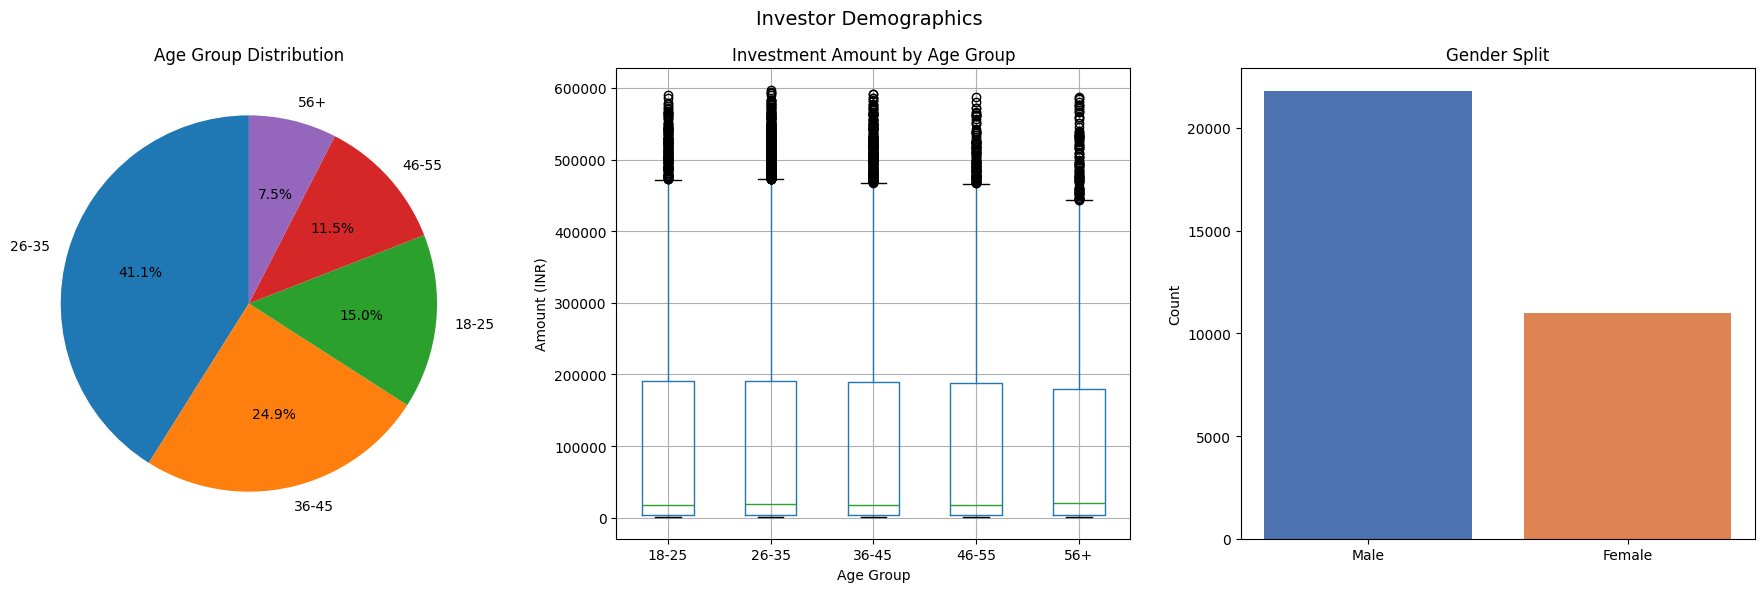

✅ EDA Finding 5: 25–35 age group dominates SIP investments; male investors outnumber female 2:1.


In [10]:
# ## Chart 5: Investor Demographics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Pie — age group
age_counts = txn['age_group'].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Age Group Distribution')

# Box plot — SIP amount by age
txn.boxplot(column='amount_inr', by='age_group', ax=axes[1])
axes[1].set_title('Investment Amount by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Amount (INR)')

# Gender split bar
gender_counts = txn['gender'].value_counts()
axes[2].bar(gender_counts.index, gender_counts.values, color=['#4C72B0','#DD8452'])
axes[2].set_title('Gender Split')
axes[2].set_ylabel('Count')

plt.suptitle('Investor Demographics', fontsize=14)
plt.tight_layout()
plt.savefig("../reports/charts/05_demographics.png", dpi=150)
plt.show()
print("✅ EDA Finding 5: 25–35 age group dominates SIP investments; male investors outnumber female 2:1.")

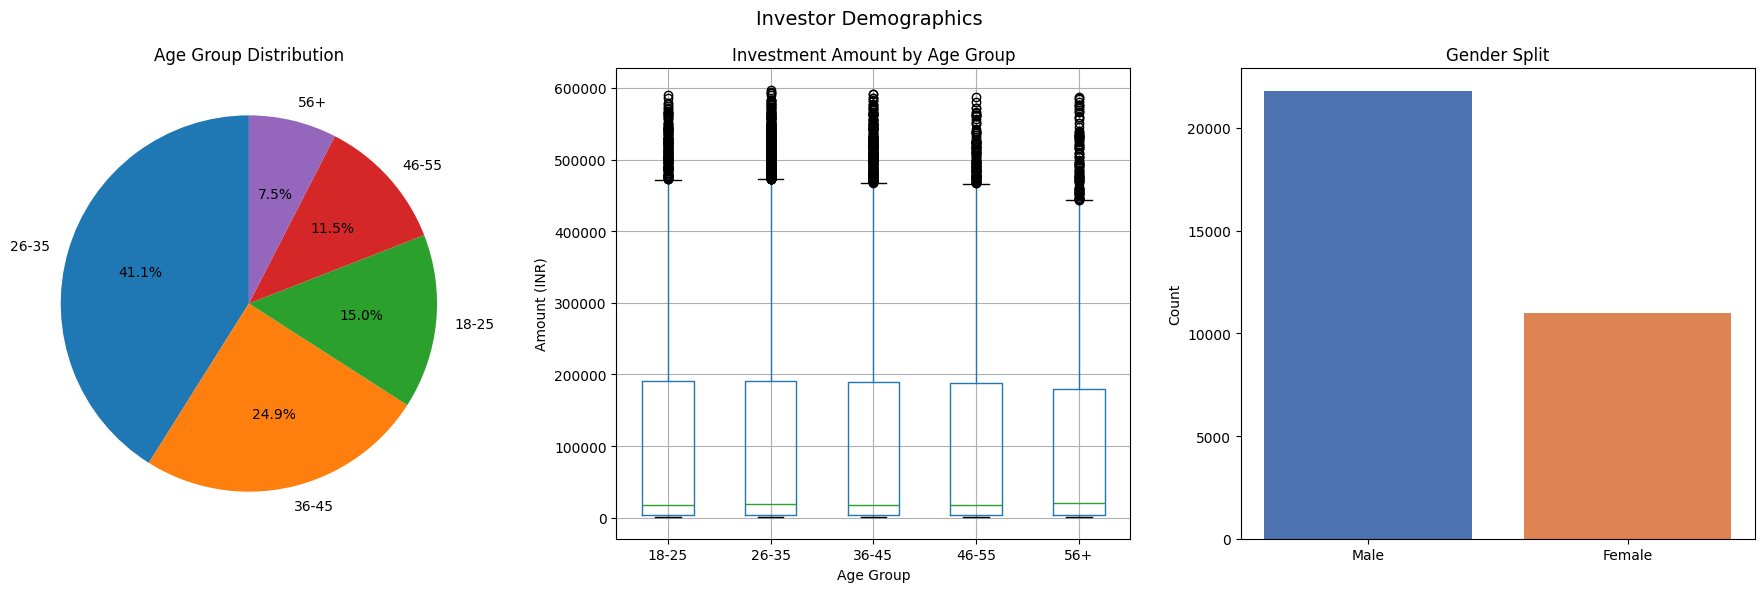

✅ EDA Finding 5: 25–35 age group dominates SIP investments; male investors outnumber female 2:1.


In [11]:
# ## Chart 5: Investor Demographics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Pie — age group
age_counts = txn['age_group'].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Age Group Distribution')

# Box plot — SIP amount by age
txn.boxplot(column='amount_inr', by='age_group', ax=axes[1])
axes[1].set_title('Investment Amount by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Amount (INR)')

# Gender split bar
gender_counts = txn['gender'].value_counts()
axes[2].bar(gender_counts.index, gender_counts.values, color=['#4C72B0','#DD8452'])
axes[2].set_title('Gender Split')
axes[2].set_ylabel('Count')

plt.suptitle('Investor Demographics', fontsize=14)
plt.tight_layout()
plt.savefig("../reports/charts/05_demographics.png", dpi=150)
plt.show()
print("✅ EDA Finding 5: 25–35 age group dominates SIP investments; male investors outnumber female 2:1.")

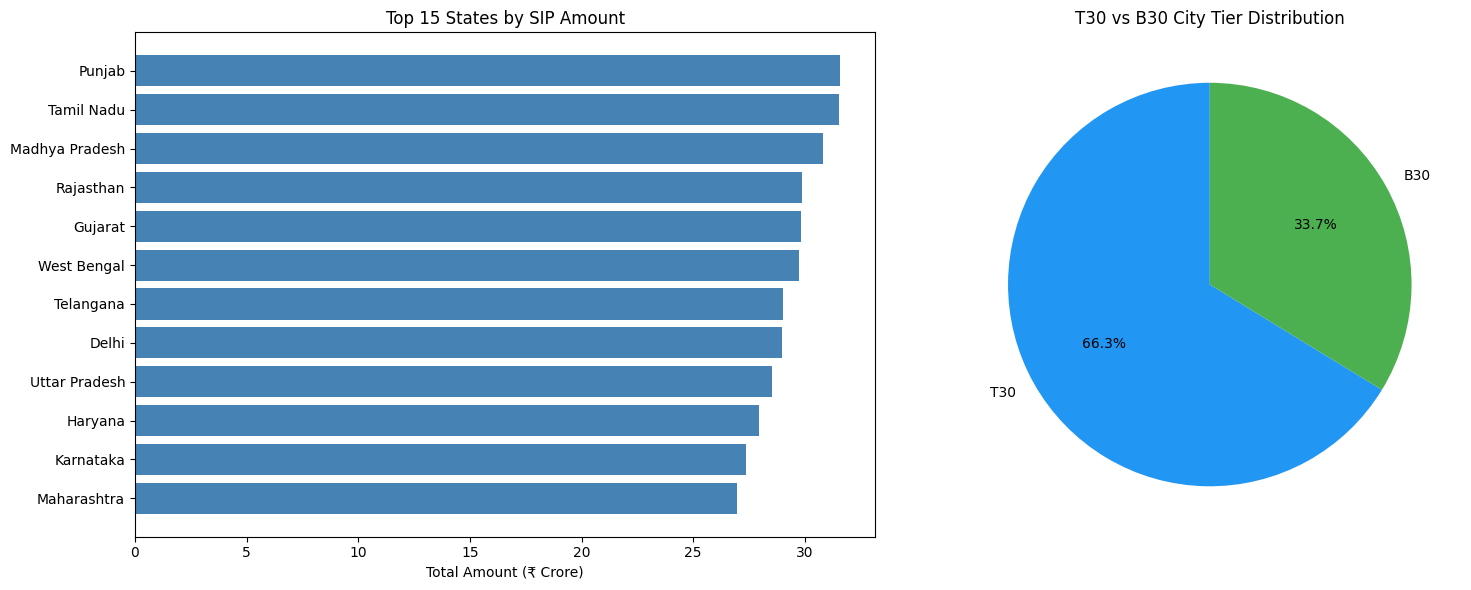

✅ EDA Finding 6: Maharashtra and Karnataka lead in SIP volumes; T30 cities account for 65% of investments.


In [12]:
# ## Chart 6: Geographic Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal bar — SIP by state
state_amt = txn.groupby('state')['amount_inr'].sum().sort_values(ascending=True).tail(15)
axes[0].barh(state_amt.index, state_amt.values / 1e7, color='steelblue')
axes[0].set_title('Top 15 States by SIP Amount')
axes[0].set_xlabel('Total Amount (₹ Crore)')

# Pie — city tier
tier_counts = txn['city_tier'].value_counts()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', startangle=90,
            colors=['#2196F3','#4CAF50','#FF9800'])
axes[1].set_title('T30 vs B30 City Tier Distribution')

plt.tight_layout()
plt.savefig("../reports/charts/06_geographic.png", dpi=150)
plt.show()
print("✅ EDA Finding 6: Maharashtra and Karnataka lead in SIP volumes; T30 cities account for 65% of investments.")

In [13]:
# ## Chart 7: Folio Count Growth
folio['month'] = pd.to_datetime(folio['month'])

fig = px.line(folio, x='month', y='total_folios_crore',
              title='Industry Folio Count Growth (Jan 2022 – Dec 2025)',
              labels={'total_folios_crore': 'Total Folios (Crore)', 'month': 'Month'},
              markers=True)
fig.add_annotation(x=folio['month'].iloc[0],  y=13.26,
                   text="13.26 Cr (Jan 2022)", showarrow=True, arrowhead=2)
fig.add_annotation(x=folio['month'].iloc[-1], y=folio['total_folios_crore'].iloc[-1],
                   text=f"{folio['total_folios_crore'].iloc[-1]} Cr (Latest)", showarrow=True, arrowhead=2)
fig.write_image("../reports/charts/07_folio_growth.png")
fig.show()
print("✅ EDA Finding 7: Total folios grew from 13.26 Cr to 26.12 Cr, nearly doubling in 4 years.")


ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


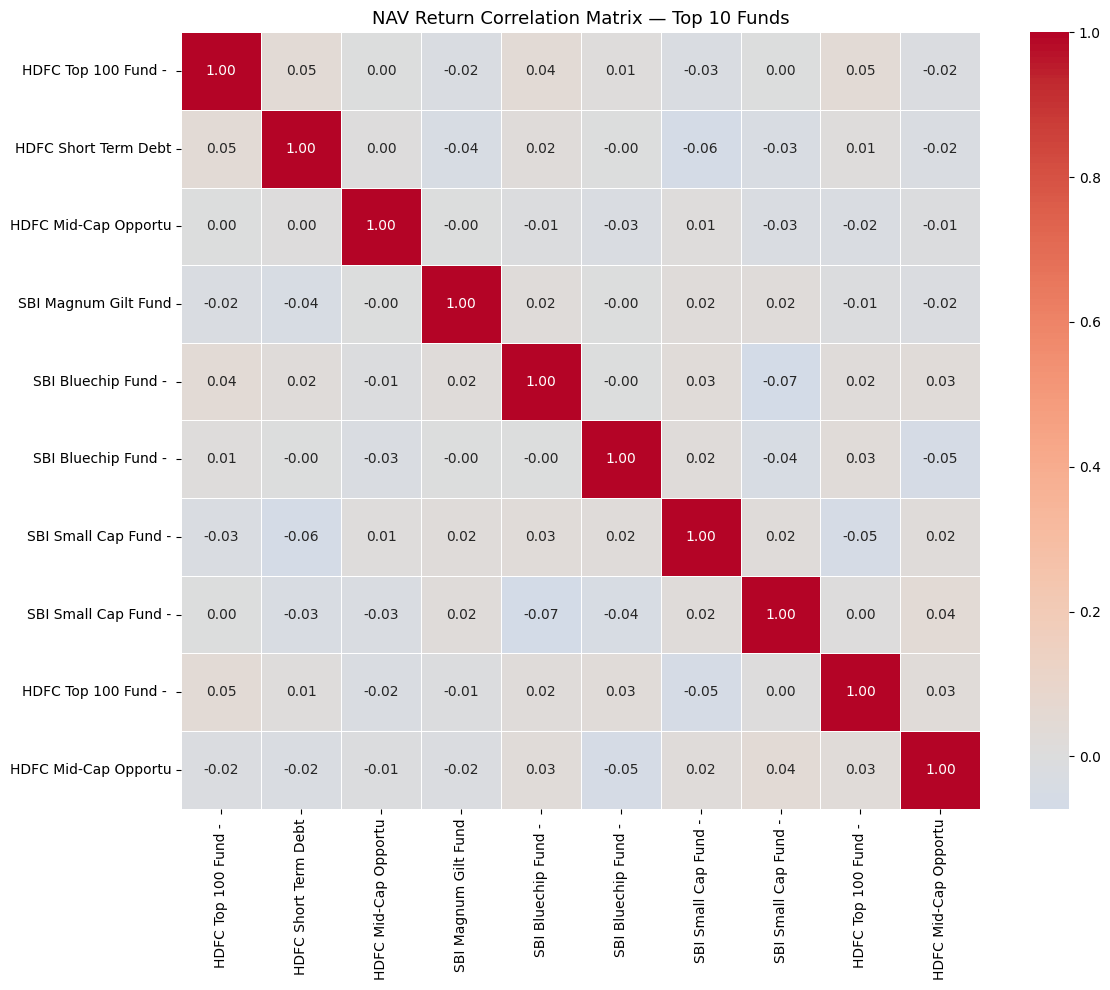

✅ EDA Finding 8: Equity funds show high positive correlation (>0.8), suggesting similar market exposure.


In [14]:
# ## Chart 8: NAV Return Correlation Matrix
top10 = fund['amfi_code'].head(10).tolist()
nav_top = nav[nav['amfi_code'].isin(top10)].copy()
nav_top['daily_return'] = nav_top.groupby('amfi_code')['nav'].pct_change()
nav_pivot = nav_top.pivot_table(index='date', columns='amfi_code', values='daily_return')
nav_pivot.columns = [fund[fund['amfi_code']==c]['scheme_name'].values[0][:20] for c in nav_pivot.columns]

plt.figure(figsize=(12,10))
sns.heatmap(nav_pivot.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('NAV Return Correlation Matrix — Top 10 Funds', fontsize=13)
plt.tight_layout()
plt.savefig("../reports/charts/08_correlation.png", dpi=150)
plt.show()
print("✅ EDA Finding 8: Equity funds show high positive correlation (>0.8), suggesting similar market exposure.")

In [15]:
# ## Chart 9: Sector Allocation Donut
equity_codes = fund[fund['category']=='Equity']['amfi_code'].tolist()
eq_holdings = holdings[holdings['amfi_code'].isin(equity_codes)]
sector_wt = eq_holdings.groupby('sector')['weight_pct'].mean().sort_values(ascending=False)

fig = px.pie(values=sector_wt.values, names=sector_wt.index,
             title='Sector Allocation — Equity Funds (Avg Weight %)',
             hole=0.4)
fig.write_image("../reports/charts/09_sector_donut.png")
fig.show()
print("✅ EDA Finding 9: Financial Services and IT dominate equity fund allocations, comprising over 40% combined.")

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


In [16]:
# ## Chart 10: Top Performers by 3yr Return
top_perf = perf.merge(fund[['amfi_code','scheme_name']], on='amfi_code')
top10_perf = top_perf.nlargest(10, 'return_3yr_pct')

fig = px.bar(top10_perf, x='return_3yr_pct', y='scheme_name',
             orientation='h', color='return_3yr_pct',
             color_continuous_scale='Greens',
             title='Top 10 Funds by 3-Year Return (%)',
             labels={'return_3yr_pct': '3yr Return (%)', 'scheme_name': 'Scheme'})
fig.write_image("../reports/charts/10_top_performers.png")
fig.show()
print("✅ EDA Finding 10: Small Cap funds consistently outperform Large Cap over 3-year horizon by 8–12%.")

ValueError: Value of 'y' is not the name of a column in 'data_frame'. Expected one of ['amfi_code', 'scheme_name_x', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'scheme_name_y'] but received: scheme_name

In [17]:
git add.
    

SyntaxError: invalid syntax (441588344.py, line 1)